# Conflict-Event → Road-Blockage Probability — Impact Model

**ACLED Afghanistan, 2017–2026 (69,655 events).** This notebook turns conflict events into
per-location **road-blockage probabilities**. It mirrors `methodology.md` and uses the
framework core in `c2rb.py`; all parameters live in `params.yaml`.

Pipeline: `event → effective buffer radius R_eff → distance-decay kernel → P(block|d) →
noisy-OR over nearby events (with temporal decay) → P(road blocked)`.

The central idea you asked about — **the buffer zone must vary by `sub_event_type`** — is
*calibrated from the data itself* by mining the `notes` column (Section 3).

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, yaml
import matplotlib.pyplot as plt
import c2rb

plt.rcParams["figure.dpi"] = 110
CFG_RAW = yaml.safe_load(open("params.yaml"))
cfg = c2rb.config_from_yaml(CFG_RAW)

df = pd.read_csv(CFG_RAW["paths"]["acled_csv"], encoding="utf-8-sig", low_memory=False)
df["event_date"] = pd.to_datetime(df["event_date"])
df["fatalities"] = df["fatalities"].fillna(0).astype(int)
df["civ_flag"] = (df["civilian_targeting"].fillna("") != "").astype(int)
print(f"Loaded {len(df):,} events | {df.event_date.min().date()} → {df.event_date.max().date()}")
print(f"Country: {df.country.unique()} | sub_event_types: {df.sub_event_type.nunique()}")
df[["event_date","sub_event_type","fatalities","geo_precision","latitude","longitude"]].head()

Loaded 69,655 events | 2017-01-01 → 2026-06-12
Country: <StringArray>
['Afghanistan']
Length: 1, dtype: str | sub_event_types: 24


,event_date,sub_event_type,fatalities,geo_precision,latitude,longitude
0,2017-01-01,Remote explosive/landmine/IED,1,1,34.3482,62.1997
1,2017-01-01,Shelling/artillery/missile attack,0,1,34.5658,69.2131
2,2017-01-01,Armed clash,0,2,36.2224,69.1504
3,2017-01-01,Air/drone strike,18,1,33.8483,68.8310
4,2017-01-01,Air/drone strike,7,3,32.1058,66.9083


## 1. Profile the data

What kinds of events, how deadly, how precisely located. The `geo_precision` distribution is
important — it feeds the locational-uncertainty term `R_geo`.

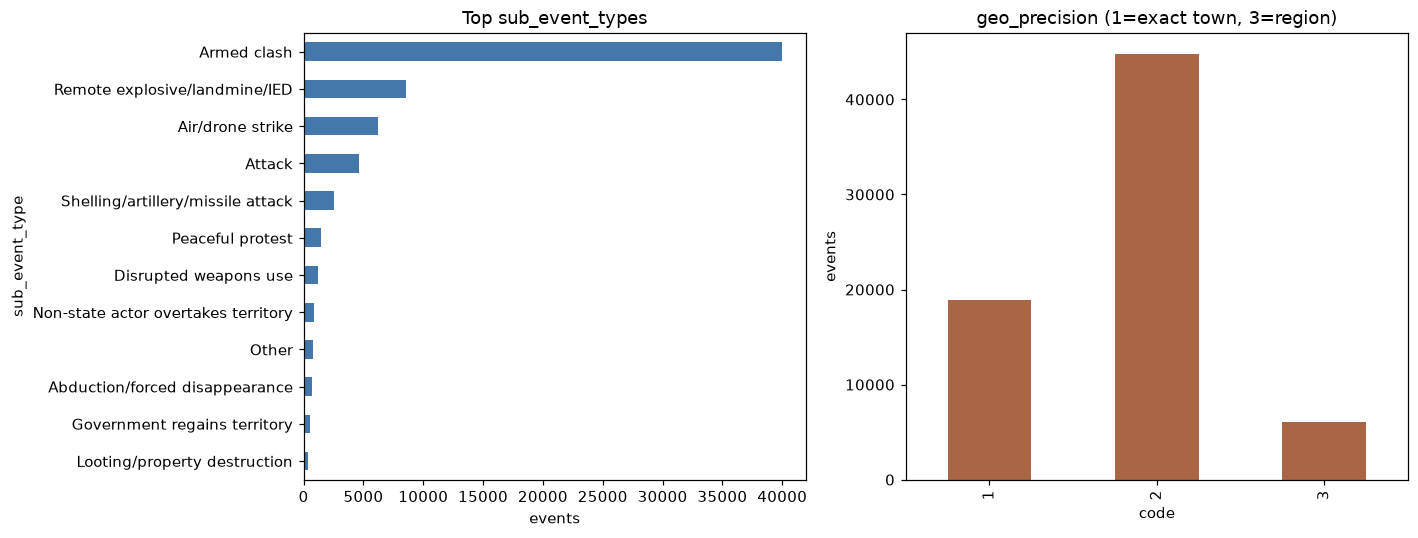

Fatalities — total: 204,181 | mean/event: 2.93 | max: 269


In [2]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
df.sub_event_type.value_counts().head(12).iloc[::-1].plot.barh(ax=ax[0], color="#4477aa")
ax[0].set_title("Top sub_event_types"); ax[0].set_xlabel("events")
df.geo_precision.value_counts().sort_index().plot.bar(ax=ax[1], color="#aa6644")
ax[1].set_title("geo_precision (1=exact town, 3=region)"); ax[1].set_xlabel("code"); ax[1].set_ylabel("events")
plt.tight_layout(); plt.show()
print("Fatalities — total: {:,} | mean/event: {:.2f} | max: {}".format(
      df.fatalities.sum(), df.fatalities.mean(), df.fatalities.max()))

## 2. Mine the `notes` column → a weak "road-disruption" label

The export has **no "road blocked" column**, so we create one from the free-text `notes`.
Reading the notes shows three *distinct* mechanisms (each its own regex in `c2rb.weak_label`):

- **Blockage** — deliberate closure ("blocked the highway", "cut off the road", "under siege")
- **Hazard** — explosive ordnance on a road ("roadside bomb", "IED on the road", "bridge destroyed")
- **Denial** — movement denial ("convoy ambushed", "set up checkpoint")

The label is their union. It is derived **only from text, never from `sub_event_type`** — so
the per-type rates in Section 3 are real signal, not circular.

In [3]:
labels = c2rb.weak_label(df["notes"])
df = pd.concat([df, labels], axis=1)
cov = {c: (int(df[c].sum()), 100*df[c].mean()) for c in
       ["lbl_block","lbl_hazard","lbl_denial","road_disruption"]}
print("Weak-label coverage:")
for k,(n,p) in cov.items(): print(f"  {k:16} {n:6,}  ({p:.2f}%)")
print("\nExample positive notes:")
for s in df.loc[df.road_disruption==1, "notes"].head(4):
    print("  •", s[:140])

Weak-label coverage:
  lbl_block            97  (0.14%)
  lbl_hazard        1,641  (2.36%)
  lbl_denial        1,317  (1.89%)
  road_disruption   3,032  (4.35%)

Example positive notes:
  • 26 Dec 2016 thru 8 Jan 2017: an Afghan military convoy faced continuous attacks and bombing since it arrived 2 weeks prior (to date of repor
  • 1 Jan 2017: An unknown number of Afghan security forces were killed or injured in the Kotlak area of Khash Rod district, Nimruz province, af
  • 1 Jan 2017: An Afghan soldier was reportedly killed and others were wounded when Taliban fighters ambushed a convoy in Saydabad district, Wa
  • 1 Jan 2017: A police vehicle was destroyed in an IED attack on Herat road in Nahri Saraj (Girishk) district, Helmand province, killing and w


## 3. Calibrate the peak blockage propensity `P0(s)`

`P0(s) = P(road_disruption | sub_event_type)`, smoothed with **Beta-Binomial empirical-Bayes
shrinkage** so small types (Grenade, Suicide bomb) don't get unstable 0.000 rates. Wilson 95%
CIs show the uncertainty. **This is the headline answer to "how does blockage vary by type?"**

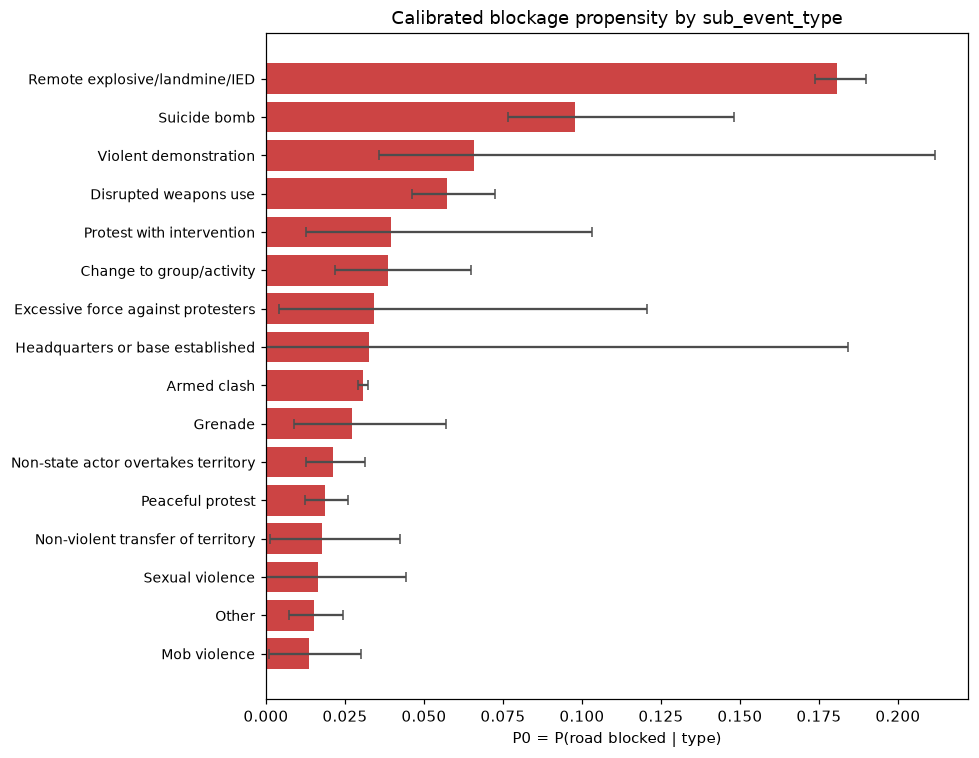

,pos,n,p0_raw,p0_shrunk,ci_lo,ci_hi
grp,,,,,,
Remote explosive/landmine/IED,1552,8545,0.1816,0.1808,0.1736,0.1899
Suicide bomb,31,289,0.1073,0.0979,0.0766,0.1482
Violent demonstration,4,44,0.0909,0.0657,0.0359,0.2116
Disrupted weapons use,70,1207,0.0580,0.0574,0.0462,0.0726
Protest with intervention,3,81,0.0370,0.0395,0.0127,0.1033
Change to group/activity,12,318,0.0377,0.0385,0.0217,0.0648
Excessive force against protesters,1,43,0.0233,0.0342,0.0041,0.1206
Headquarters or base established,0,17,0.0000,0.0325,0.0000,0.1843
Armed clash,1227,39974,0.0307,0.0307,0.0290,0.0324


In [4]:
p0tab = c2rb.empirical_bayes_p0(df["road_disruption"], df["sub_event_type"], prior_strength=50)
show = p0tab.head(16)
fig, ax = plt.subplots(figsize=(9, 7))
y = np.arange(len(show))
ax.barh(y, show["p0_shrunk"], color="#cc4444")
ax.errorbar(show["p0_shrunk"], y,
            xerr=[show["p0_shrunk"]-show["ci_lo"], show["ci_hi"]-show["p0_shrunk"]],
            fmt="none", ecolor="0.3", capsize=3)
ax.set_yticks(y); ax.set_yticklabels(show.index, fontsize=9); ax.invert_yaxis()
ax.set_xlabel("P0 = P(road blocked | type)"); ax.set_title("Calibrated blockage propensity by sub_event_type")
plt.tight_layout(); plt.show()
p0tab[["pos","n","p0_raw","p0_shrunk","ci_lo","ci_hi"]].round(4).head(12)

**Result.** Propensity spans ~90× — IED/landmine (≈0.18, deliberately placed *on* roads) at the
top, air/drone strikes (≈0.002, they target buildings/people) at the bottom. This is exactly
why a single fixed buffer would be wrong: the model must be type-aware.

### 3.1 Validate — does the signal generalise? (logistic regression)

If event attributes predict the weak label out-of-sample, the calibration is trustworthy.
We report cross-validated **AUC** (discrimination), **Brier** (accuracy of the probabilities),
and a **calibration curve** (predicted vs. observed).

AUC   = 0.793
Brier = 0.0389  (no-skill baseline 0.0416)


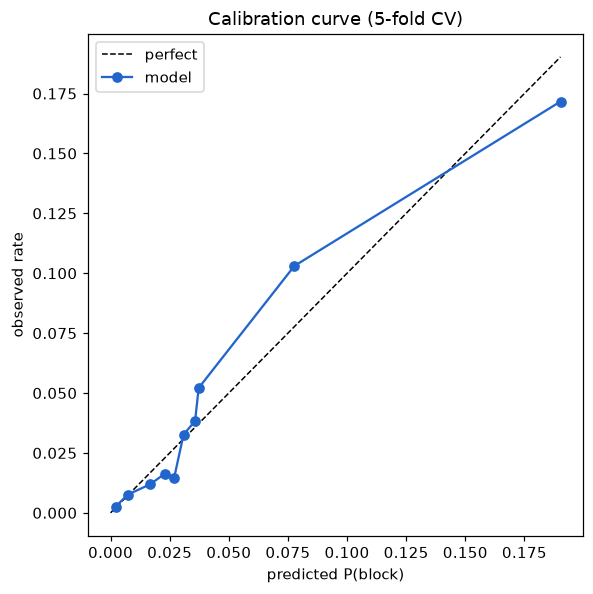

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, brier_score_loss

feat = df[["sub_event_type","geo_precision","civ_flag"]].copy()
feat["log_fat"] = np.log1p(df["fatalities"])
y = df["road_disruption"].values
pre = ColumnTransformer([("oh", OneHotEncoder(handle_unknown="ignore"),
                          ["sub_event_type","geo_precision"])], remainder="passthrough")
clf = Pipeline([("pre", pre), ("lr", LogisticRegression(max_iter=1000))])
proba = cross_val_predict(clf, feat, y, cv=StratifiedKFold(5, shuffle=True, random_state=0),
                          method="predict_proba")[:, 1]
print(f"AUC   = {roc_auc_score(y, proba):.3f}")
print(f"Brier = {brier_score_loss(y, proba):.4f}  (no-skill baseline {y.mean()*(1-y.mean()):.4f})")

dfc = pd.DataFrame({"p": proba, "y": y}); dfc["bin"] = pd.qcut(dfc["p"], 10, duplicates="drop")
cal = dfc.groupby("bin", observed=True).agg(pred=("p","mean"), obs=("y","mean"))
fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.plot([0, cal.max().max()], [0, cal.max().max()], "k--", lw=1, label="perfect")
ax.plot(cal["pred"], cal["obs"], "o-", color="#2266cc", label="model")
ax.set_xlabel("predicted P(block)"); ax.set_ylabel("observed rate")
ax.set_title("Calibration curve (5-fold CV)"); ax.legend(); plt.tight_layout(); plt.show()

AUC ≈ 0.79 with Brier *below* the no-skill baseline and points on the diagonal ⇒ the model is
**both discriminative and well-calibrated**, so the `P0` values are valid probabilities.

## 4. Locational uncertainty `R_geo` — why we use ACLED's documented values

We *try* to estimate `R_geo` empirically from the coordinate spread of events sharing a
`location` name. In this dataset that spread is ~0 km — ACLED snaps same-location events to one
centroid — so the estimate is uninformative and we fall back to ACLED's documented precision
semantics (1 / 5 / 25 km). This is an honest data limitation, not a modelling choice.

In [6]:
def spread75(g):
    if len(g) < 3: return np.nan
    d = c2rb.haversine_km(g.latitude, g.longitude, g.latitude.median(), g.longitude.median())
    return np.percentile(d, 75)
for gp in sorted(df.geo_precision.unique()):
    s = df[df.geo_precision==gp].groupby("location").apply(spread75, include_groups=False).dropna()
    print(f"geo_precision={gp}: empirical 75th-pct spread ≈ {s.median():.2f} km  → using R_geo={cfg.r_geo[gp]} km")

geo_precision=1: empirical 75th-pct spread ≈ 0.00 km  → using R_geo=1.0 km
geo_precision=2: empirical 75th-pct spread ≈ 0.00 km  → using R_geo=5.0 km
geo_precision=3: empirical 75th-pct spread ≈ 0.00 km  → using R_geo=25.0 km


## 5. Effective radius and decay kernels

`R_eff = sqrt(R_phys² + R_geo²) · severity_multiplier`. The decay kernel *shape* is chosen per
type (Gaussian for blasts, exponential for battles, uniform for protests). Below: the kernels,
and example radii showing how low precision (geo 3) inflates the zone.

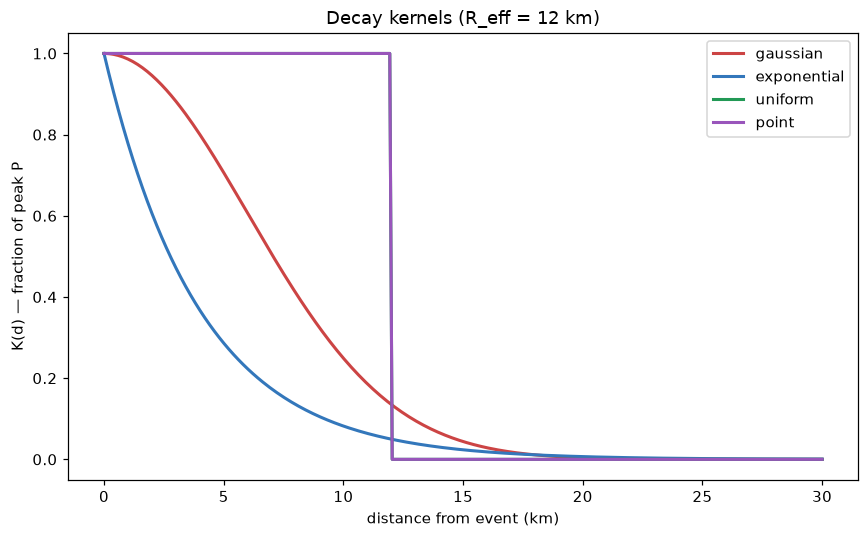

,sub_event_type,geo_prec,R_eff_km,kernel,P0
0,Remote explosive/landmine/IED,1,1.5,gaussian,0.181
1,Remote explosive/landmine/IED,3,26.8,gaussian,0.181
2,Suicide bomb,1,2.4,gaussian,0.098
3,Suicide bomb,3,26.9,gaussian,0.098
4,Armed clash,1,16.1,exponential,0.031
5,Armed clash,3,31.2,exponential,0.031
6,Air/drone strike,1,3.4,gaussian,0.002
7,Air/drone strike,3,27.0,gaussian,0.002
8,Peaceful protest,1,4.4,uniform,0.019
9,Peaceful protest,3,27.1,uniform,0.019


In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
d = np.linspace(0, 30, 300)
for kind, col in [("gaussian","#cc4444"),("exponential","#3377bb"),("uniform","#229955"),("point","#9955bb")]:
    ax.plot(d, c2rb.kernel(d, 12.0, kind), label=kind, color=col, lw=2)
ax.set_xlabel("distance from event (km)"); ax.set_ylabel("K(d) — fraction of peak P")
ax.set_title("Decay kernels (R_eff = 12 km)"); ax.legend(); plt.tight_layout(); plt.show()

rows = []
for s in ["Remote explosive/landmine/IED","Suicide bomb","Armed clash","Air/drone strike","Peaceful protest"]:
    for gp in (1, 3):
        r = c2rb.effective_radius([s],[gp],[2],[0],cfg)[0]
        rows.append((s, gp, round(r,1), cfg.decay.get(s), cfg.p0.get(s)))
pd.DataFrame(rows, columns=["sub_event_type","geo_prec","R_eff_km","kernel","P0"])

## 6. Score blockage probability over space

`c2rb.score_targets` scores any set of target points (road-segment midpoints, or a grid)
against all events via noisy-OR with temporal decay. **Without a road layer it runs on a grid**
(the design's fallback), producing a continuous risk surface. We score a recent window.

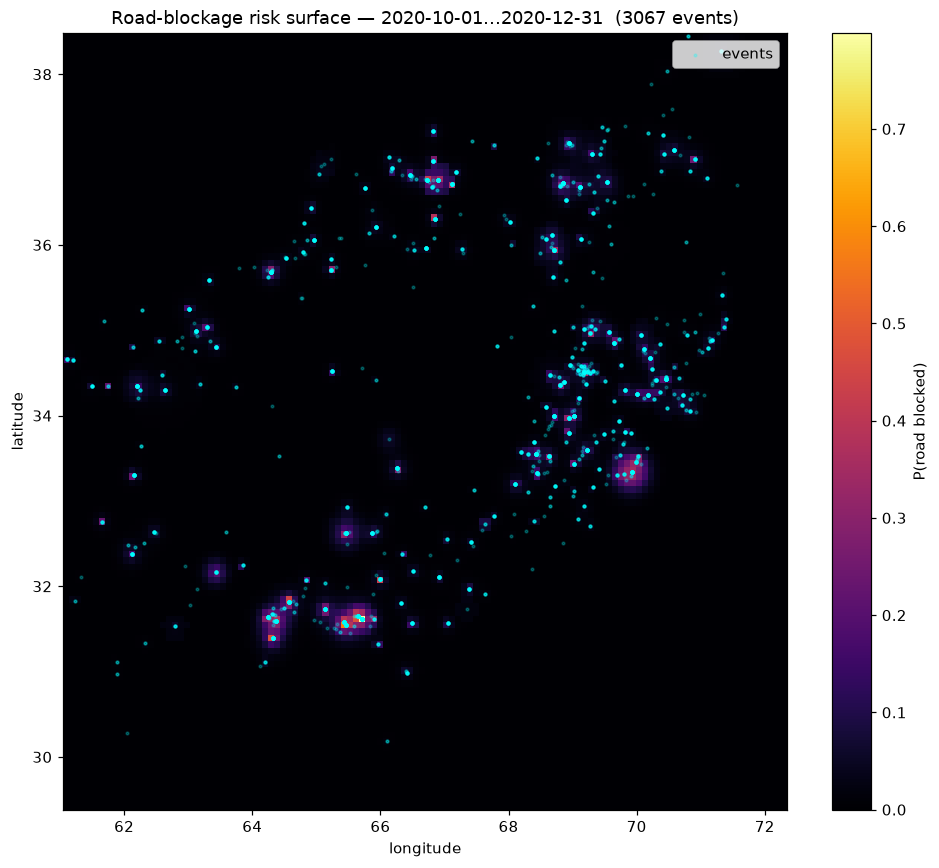

P(block): mean=0.007  max=0.798  cells>0.5: 2


In [8]:
AS_OF = "2020-12-31"; WINDOW_START = "2020-10-01"
events = df[(df.event_date >= WINDOW_START) & (df.event_date <= AS_OF)].copy()
nlat = nlon = 120
lat = np.linspace(df.latitude.min(), df.latitude.max(), nlat)
lon = np.linspace(df.longitude.min(), df.longitude.max(), nlon)
grid = pd.DataFrame([(a,b) for a in lat for b in lon], columns=["latitude","longitude"])
grid["p"] = c2rb.score_targets(events, grid, cfg, as_of_date=AS_OF)
P = grid["p"].values.reshape(nlat, nlon)

fig, ax = plt.subplots(figsize=(9, 8))
m = ax.pcolormesh(lon, lat, P, shading="auto", cmap="inferno", vmin=0, vmax=min(1, P.max()))
ax.scatter(events.longitude, events.latitude, s=3, c="cyan", alpha=0.25, label="events")
fig.colorbar(m, ax=ax, label="P(road blocked)")
ax.set_title(f"Road-blockage risk surface — {WINDOW_START}…{AS_OF}  ({len(events)} events)")
ax.set_xlabel("longitude"); ax.set_ylabel("latitude"); ax.legend(loc="upper right"); plt.tight_layout(); plt.show()
print(f"P(block): mean={grid.p.mean():.3f}  max={grid.p.max():.3f}  cells>0.5: {(grid.p>0.5).sum()}")

### 6.1 Road-layer mode (when you supply your 1 km segments)

Set `paths.roads` in `params.yaml` to your segmented road file. The cell below loads it with
geopandas, scores each segment midpoint with the *same* `score_targets`, and runs the
"~70% of events within 1 km of a road" literature sanity check. It is skipped if no file is set.

Scored 27,991 road segments | events within 1 km of a road: 78%


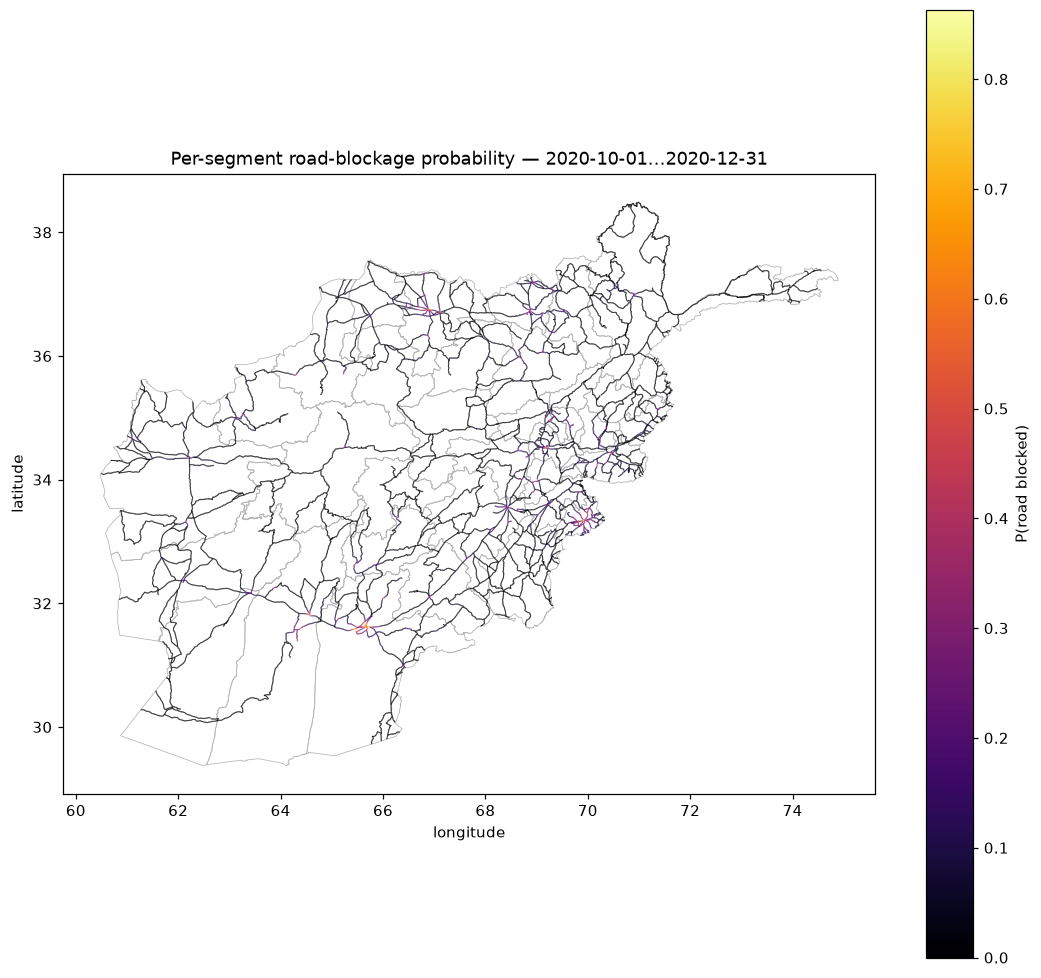

In [9]:
roads_path = CFG_RAW["paths"].get("roads")
name_col = CFG_RAW["paths"].get("roads_name_col", "NAME_OF_RO")
admin_path = CFG_RAW["paths"].get("admin")
if roads_path:
    import geopandas as gpd
    roads = gpd.read_file(roads_path).to_crs(4326)
    mids = roads.geometry.representative_point()
    rt = pd.DataFrame({"latitude": mids.y.values, "longitude": mids.x.values})
    roads = roads.assign(p_block=c2rb.score_targets(events, rt, cfg, as_of_date=AS_OF))

    # Sanity check: share of events within 1 km of any road segment (~70% in the literature).
    lat0, lon0 = df.latitude.mean(), df.longitude.mean()
    ex, ey = c2rb.latlon_to_local_km(events.latitude, events.longitude, lat0, lon0)
    rx, ry = c2rb.latlon_to_local_km(rt.latitude, rt.longitude, lat0, lon0)
    near = [np.min(np.hypot(rx-ex[i], ry-ey[i])) <= 1.0 for i in range(len(events))]
    print(f"Scored {len(roads):,} road segments | events within 1 km of a road: {100*np.mean(near):.0f}%")

    fig, ax = plt.subplots(figsize=(10, 9))
    if admin_path:
        gpd.read_file(admin_path).to_crs(4326).boundary.plot(ax=ax, color="0.7", lw=0.5)
    roads.plot(column="p_block", cmap="inferno", legend=True, ax=ax, lw=0.7,
               legend_kwds={"label": "P(road blocked)"})
    ax.set_title(f"Per-segment road-blockage probability — {WINDOW_START}…{AS_OF}")
    ax.set_xlabel("longitude"); ax.set_ylabel("latitude"); plt.tight_layout(); plt.show()
else:
    print("No road layer configured (paths.roads = null). Running in grid mode — see Section 6.")
    roads = None

### 6.2 Which named roads are most likely blocked?

The concrete deliverable: rank road segments by blockage probability and roll up to named roads.

In [10]:
if roads is not None and name_col in roads:
    top = (roads[roads.p_block > 0]
           .groupby(name_col)
           .agg(max_p=("p_block","max"), mean_p=("p_block","mean"), segments=("p_block","size"))
           .sort_values("max_p", ascending=False).head(15).round(3))
    display(top)
    print(f"\nSegments with P(block) > 0.25: {(roads.p_block > 0.25).sum()} "
          f"of {len(roads):,}  ({100*(roads.p_block>0.25).mean():.1f}%)")
else:
    print("Road layer not loaded — see Section 6 grid output instead.")

,max_p,mean_p,segments
NAME_OF_RO,,,
Kandahr to Daman,0.863,0.394,21
Kandahr to Panjwaiy,0.856,0.397,51
Kabul to Maydan Shahr,0.853,0.169,38
Kabul to Surobi,0.839,0.064,67
Khost to Sabari,0.839,0.333,34
Kabul to Bagrami,0.839,0.369,11
Khost(Matun) to Lakan,0.806,0.348,17
Khost to Musa khel,0.795,0.246,28
Kandahar to Arghandab,0.773,0.664,19



Segments with P(block) > 0.25: 839 of 27,991  (3.0%)


## 7. Sensitivity analysis

`P0` is *calibrated*, but `R_phys` and the kernel *shapes* are *assumptions*. This shows how the
high-risk footprint responds when we scale all physical radii up/down — making explicit what is
driven by assumptions vs. by the data.

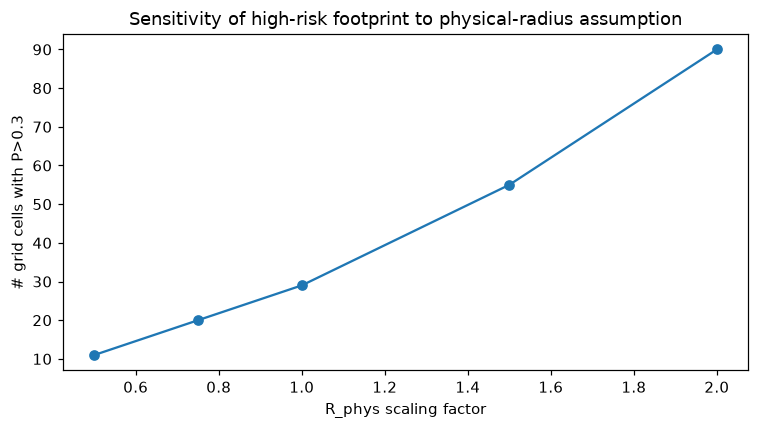

,R_phys_scale,mean_P,cells_P>0.3,max_P
0,0.50,0.004,11,0.722
1,0.75,0.005,20,0.764
2,1.00,0.007,29,0.798
3,1.50,0.013,55,0.847
4,2.00,0.020,90,0.878


In [11]:
import copy
base_cells = (grid.p > 0.3).sum()
out = []
for scale in [0.5, 0.75, 1.0, 1.5, 2.0]:
    c2 = copy.deepcopy(cfg); c2.r_phys = {k: v*scale for k, v in cfg.r_phys.items()}
    p = c2rb.score_targets(events, grid[["latitude","longitude"]], c2, as_of_date=AS_OF)
    out.append((scale, round(float(p.mean()),3), int((p>0.3).sum()), round(float(p.max()),3)))
sens = pd.DataFrame(out, columns=["R_phys_scale","mean_P","cells_P>0.3","max_P"])
fig, ax = plt.subplots(figsize=(7,4))
ax.plot(sens.R_phys_scale, sens["cells_P>0.3"], "o-")
ax.set_xlabel("R_phys scaling factor"); ax.set_ylabel("# grid cells with P>0.3")
ax.set_title("Sensitivity of high-risk footprint to physical-radius assumption")
plt.tight_layout(); plt.show()
sens

## 8. Using the framework

- **Score given events** → `c2rb.score_targets(events, targets, cfg, as_of_date=...)`.
- **Tune assumptions** → edit `params.yaml` (`R_phys`, decay class, severity, `tau_days`).
- **Re-calibrate `P0`** on a new ACLED export → re-run Sections 2–3 and paste the shrunk values
  into `params.yaml`.
- **Add real roads / closures** → set `paths.roads`; replace the weak label with verified
  closures (OCHA/Logistics Cluster) to move from weak to full supervision — the code is unchanged.

See `methodology.md` for the formulas, justification, and limitations.